# Adaptive CMOS Inverter Optimization using Open-Source Tools

## 1. Introduction
This project explores the trade-off between power and delay in CMOS inverter design using automated simulations.

## 2. Circuit Design
A CMOS inverter is simulated using ngspice.

## 3. Parameter Sweep
Multiple parameters such as VDD, transistor width, and load capacitance are varied.

## 4. Results
Power, delay, and Power-Delay Product (PDP) are analyzed.

## 5. Visualization
Heatmaps and 3D plots are used to identify optimal design points.

## 6. Conclusion
Optimal design trade-offs are discussed.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [10]:
VDD_list = [0.8, 1.0, 1.2, 1.5, 1.8]           # Supply voltage (Volts)

WN_list = [1e-6, 2e-6, 3e-6, 4e-6]        # NMOS width (meters)
WP_list = [2e-6, 4e-6, 6e-6, 8e-6]        # PMOS width (meters)

CL_list = [1e-15, 3e-15, 5e-15, 1e-14]     # Load capacitance (Farads)

results = []                        # To store simulation outputs

In [11]:
for VDD in VDD_list:
    for WN in WN_list:
        for WP in WP_list:
            for CL in CL_list:

                #  CREATE NETLIST (MISSING PART)
                netlist = f"""
* CMOS Inverter

Vdd vdd 0 DC {VDD}
Vin in 0 PULSE(0 {VDD} 0 1n 1n 10n 20n)

M1 out in 0 0 NMOS L=0.18u W={WN}
M2 out in vdd vdd PMOS L=0.18u W={WP}

Cload out 0 {CL}

.model NMOS nmos level=1
.model PMOS pmos level=1

.tran 0.1n 50n

.control
run
meas tran delay TRIG v(in) VAL={VDD/2} RISE=1 TARG v(out) VAL={VDD/2} FALL=1
meas tran power AVG i(Vdd)
print delay power
.endc

.end
"""

                #  WRITE FILE
                with open("temp.sp", "w") as f:
                    f.write(netlist)

                #  RUN NGSPICE
                os.system("ngspice -b temp.sp -o log.txt")

                delay = None
                power = None

                #  PARSE OUTPUT
                with open("log.txt", "r") as log:
                    for line in log:
                        if "delay =" in line:
                            try:
                                delay = float(line.split("=")[1])
                            except:
                                pass
                        if "power =" in line:
                            try:
                                power = abs(float(line.split("=")[1]))
                            except:
                                pass

                #  STORE RESULTS
                if delay is not None and power is not None:
                    pdp = abs(delay * power)
                    results.append([VDD, WN, WP, CL, delay, power, pdp])
                    print("STORED:", VDD, WN, WP, CL)
                    print("Samples:", results[:3])

#  FINAL COUNT
print("FINAL simulations:", len(results))

STORED: 0.8 1e-06 2e-06 1e-15
Samples: [[0.8, 1e-06, 2e-06, 1e-15, 1.381601e-10, 4.13573e-07, 5.71392870373e-17]]
STORED: 0.8 1e-06 2e-06 3e-15
Samples: [[0.8, 1e-06, 2e-06, 1e-15, 1.381601e-10, 4.13573e-07, 5.71392870373e-17], [0.8, 1e-06, 2e-06, 3e-15, 1.994081e-10, 4.41328e-07, 8.80043779568e-17]]
STORED: 0.8 1e-06 2e-06 5e-15
Samples: [[0.8, 1e-06, 2e-06, 1e-15, 1.381601e-10, 4.13573e-07, 5.71392870373e-17], [0.8, 1e-06, 2e-06, 3e-15, 1.994081e-10, 4.41328e-07, 8.80043779568e-17], [0.8, 1e-06, 2e-06, 5e-15, 2.442063e-10, 4.76922e-07, 1.164673570086e-16]]
STORED: 0.8 1e-06 2e-06 1e-14
Samples: [[0.8, 1e-06, 2e-06, 1e-15, 1.381601e-10, 4.13573e-07, 5.71392870373e-17], [0.8, 1e-06, 2e-06, 3e-15, 1.994081e-10, 4.41328e-07, 8.80043779568e-17], [0.8, 1e-06, 2e-06, 5e-15, 2.442063e-10, 4.76922e-07, 1.164673570086e-16]]
STORED: 0.8 1e-06 4e-06 1e-15
Samples: [[0.8, 1e-06, 2e-06, 1e-15, 1.381601e-10, 4.13573e-07, 5.71392870373e-17], [0.8, 1e-06, 2e-06, 3e-15, 1.994081e-10, 4.41328e-07, 8.80

In [12]:
import pandas as pd

df = pd.DataFrame(results, columns=[
    "VDD", "WN", "WP", "CL", "Delay", "Power", "PDP"
])

df.head()
df.describe()

,VDD,WN,WP,CL,Delay,Power,PDP
count,320.000000,320.000000,320.000000,3.200000e+02,3.200000e+02,3.200000e+02,3.200000e+02
mean,1.260000,0.000002,0.000005,4.750000e-15,1.510920e-10,2.576571e-06,3.668326e-16
std,0.356085,0.000001,0.000002,3.350011e-15,1.088306e-10,1.728021e-06,2.945231e-16
min,0.800000,0.000001,0.000002,1.000000e-15,-9.793770e-11,4.135730e-07,8.633547e-20
25%,1.000000,0.000002,0.000003,2.500000e-15,7.909392e-11,1.269565e-06,1.452103e-16
50%,1.200000,0.000002,0.000005,4.000000e-15,1.470095e-10,2.119735e-06,2.938338e-16
75%,1.500000,0.000003,0.000007,6.250000e-15,2.230523e-10,3.395770e-06,5.194102e-16
max,1.800000,0.000004,0.000008,1.000000e-14,4.339817e-10,8.400190e-06,1.392819e-15


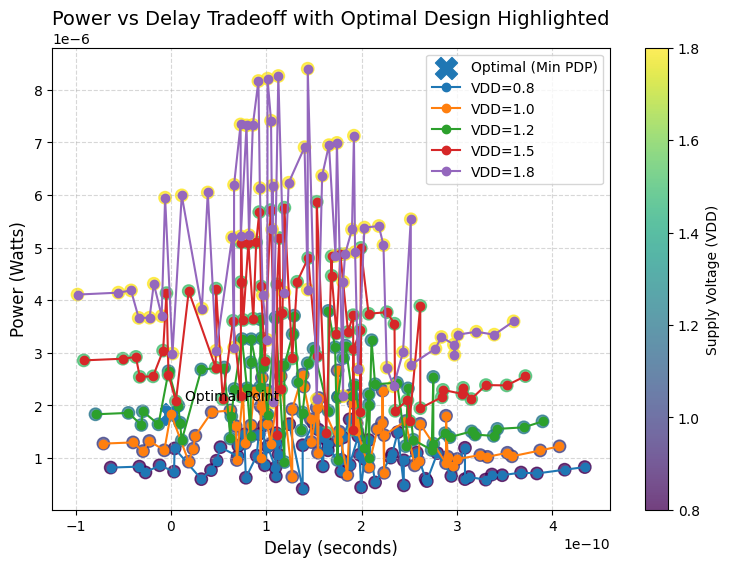

In [13]:
best = df.loc[df["PDP"].idxmin()]

plt.figure(figsize=(9,6))

# Main scatter
scatter = plt.scatter(
    df["Delay"], 
    df["Power"], 
    c=df["VDD"],
    s=80,
    alpha=0.75
)

# Highlight optimal point
plt.scatter(
    best["Delay"], 
    best["Power"], 
    marker='X', 
    s=250,
    label="Optimal (Min PDP)"
)

# Annotate best point
plt.annotate(
    "Optimal Point",
    (best["Delay"], best["Power"]),
    textcoords="offset points",
    xytext=(10,10)
)

for vdd in sorted(df["VDD"].unique()):
    subset = df[df["VDD"] == vdd].sort_values("Delay")
    plt.plot(subset["Delay"], subset["Power"], marker='o', label=f"VDD={vdd}")

plt.xlabel("Delay (seconds)", fontsize=12)
plt.ylabel("Power (Watts)", fontsize=12)
plt.title("Power vs Delay Tradeoff with Optimal Design Highlighted", fontsize=14)

cbar = plt.colorbar(scatter)
cbar.set_label("Supply Voltage (VDD)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Power vs Delay Analysis

The plot clearly illustrates the fundamental trade-off between delay and power in CMOS inverter design.

- Increasing supply voltage (VDD) improves switching speed (reduces delay) but increases power consumption.
- Different clusters represent varying transistor sizing and load conditions.
- The highlighted optimal point corresponds to the minimum Power-Delay Product (PDP), indicating the best balance between speed and energy efficiency.
- This demonstrates how design parameters can be tuned to achieve optimal performance using data-driven exploration.

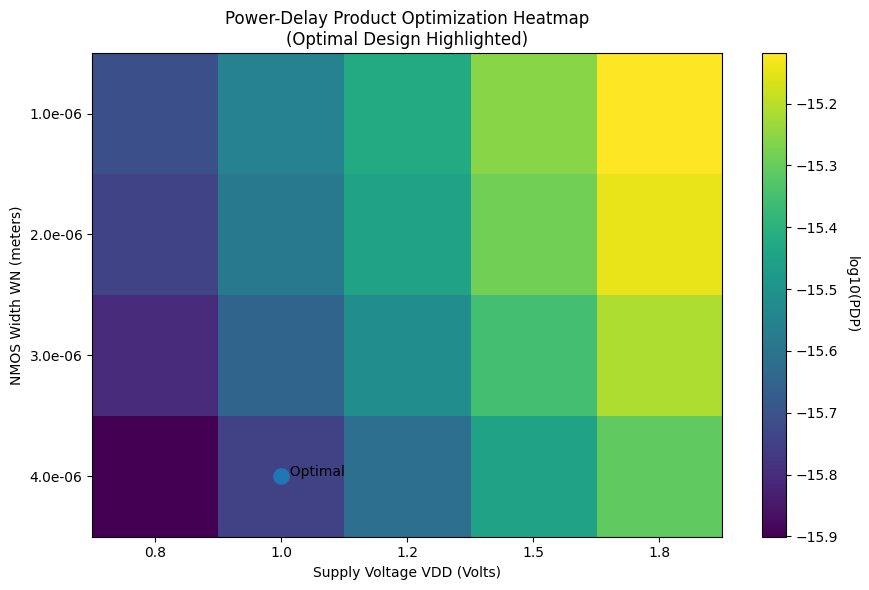

Optimal Design Configuration:
VDD      1.000000e+00
WN       4.000000e-06
WP       4.000000e-06
CL       1.000000e-15
Delay   -4.690590e-14
Power    1.840610e-06
PDP      8.633547e-20
Name: 116, dtype: float64


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Create Pivot Table ----
pivot = df.pivot_table(
    values="PDP",
    index="WN",
    columns="VDD",
    aggfunc="mean"
)

# ---- Log Scale ----
log_pivot = np.log10(pivot)

# ---- Find Optimal Point ----
best = df.loc[df["PDP"].idxmin()]
best_vdd = best["VDD"]
best_wn = best["WN"]

x_idx = list(pivot.columns).index(best_vdd)
y_idx = list(pivot.index).index(best_wn)

# ---- Single Clean Plot ----
plt.figure(figsize=(9,6))

img = plt.imshow(log_pivot, aspect='auto')

# Highlight optimal point
plt.scatter(x_idx, y_idx, s=120, marker='o')
plt.text(x_idx, y_idx, "  Optimal", fontsize=10)

# Colorbar
cbar = plt.colorbar(img)
cbar.set_label("log10(PDP)", rotation=270, labelpad=15)

# Axis formatting
plt.xticks(range(len(pivot.columns)), [f"{v:.1f}" for v in pivot.columns])
plt.yticks(range(len(pivot.index)), [f"{w:.1e}" for w in pivot.index])

plt.xlabel("Supply Voltage VDD (Volts)")
plt.ylabel("NMOS Width WN (meters)")

plt.title("Power-Delay Product Optimization Heatmap\n(Optimal Design Highlighted)")

plt.tight_layout()
plt.show()

# ---- Print Best ----
print("Optimal Design Configuration:")
print(best)

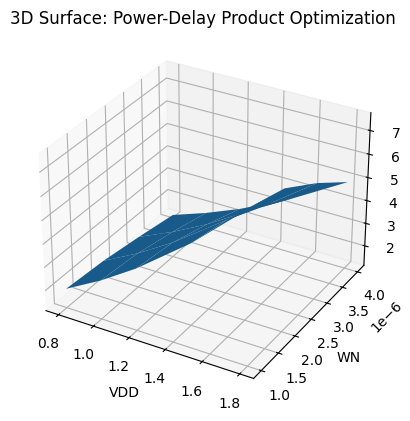

In [16]:
# Ensure PDP is numeric
df["PDP"] = pd.to_numeric(df["PDP"], errors="coerce")

# Create pivot table
pivot = df.pivot_table(values="PDP", index="WN", columns="VDD", aggfunc='mean')

# Fill missing values
pivot = pivot.fillna(0)

# Convert to arrays
X = pivot.columns.values.astype(float)
Y = pivot.index.values.astype(float)

X, Y = np.meshgrid(X, Y)
Z = pivot.values.astype(float)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

ax.set_xlabel("VDD")
ax.set_ylabel("WN")
ax.set_zlabel("PDP")

plt.title("3D Surface: Power-Delay Product Optimization")
plt.show()

   OPTIMAL CMOS INVERTER DESIGN

VDD        : 1.0 V
WN         : 4e-06 m
WP         : 4e-06 m
CL         : 1e-15 F

Performance Metrics:
Delay      : -4.691e-14 s
Power      : 1.841e-06 W
PDP        : 8.634e-20


Top 5 Optimal Configurations:

     VDD        WN        WP            CL         Delay         Power  \
116  1.0  0.000004  0.000004  1.000000e-15 -4.690590e-14  1.840610e-06   
33   0.8  0.000003  0.000002  3.000000e-15  3.272846e-12  7.385170e-07   
52   0.8  0.000004  0.000004  1.000000e-15  3.878902e-12  1.179990e-06   
272  1.8  0.000002  0.000002  1.000000e-15  1.649342e-12  2.984000e-06   
180  1.2  0.000004  0.000004  1.000000e-15 -2.438660e-12  2.647650e-06   

              PDP  
116  8.633547e-20  
33   2.417052e-18  
52   4.577066e-18  
272  4.921637e-18  
180  6.456718e-18  


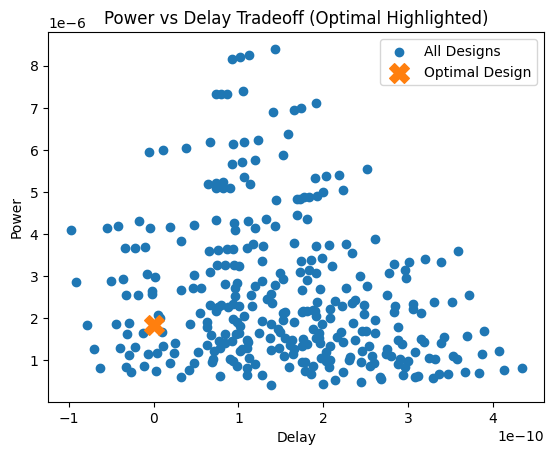

In [17]:
best = df.loc[df["PDP"].idxmin()]

print("===================================")
print("   OPTIMAL CMOS INVERTER DESIGN")
print("===================================\n")

print(f"VDD        : {best['VDD']} V")
print(f"WN         : {best['WN']} m")
print(f"WP         : {best['WP']} m")
print(f"CL         : {best['CL']} F")

print("\nPerformance Metrics:")
print(f"Delay      : {best['Delay']:.3e} s")
print(f"Power      : {best['Power']:.3e} W")
print(f"PDP        : {best['PDP']:.3e}")

print("\n===================================")


# 2. Show Top 5 Best Designs (for analysis depth)
print("\nTop 5 Optimal Configurations:\n")
top5 = df.nsmallest(5, "PDP")
print(top5)


# 3. Highlight optimal point on Power vs Delay plot
plt.figure()

plt.scatter(df["Delay"], df["Power"], label="All Designs")

plt.scatter(best["Delay"], best["Power"],
            marker='X', s=200, label="Optimal Design")

plt.xlabel("Delay")
plt.ylabel("Power")
plt.title("Power vs Delay Tradeoff (Optimal Highlighted)")
plt.legend()

plt.show()

### Optimal Design Insight

The optimal inverter configuration is determined by minimizing the Power-Delay Product (PDP), which balances speed and power efficiency.

- Lower PDP indicates better overall performance.
- Higher VDD reduces delay but increases power consumption.
- Increasing transistor width improves speed but increases power.

The highlighted point in the graph represents the best trade-off among all simulated configurations.

This demonstrates how data-driven optimization can guide efficient circuit design using open-source tools.

### Conclusion

This project presented a systematic and reproducible approach to CMOS inverter optimization using open-source simulation and data-driven analysis. By sweeping key design parameters such as supply voltage (VDD), transistor sizing (WN/WP), and load capacitance (CL), the fundamental trade-off between power consumption and propagation delay was thoroughly explored.

The results demonstrate that increasing VDD reduces delay but significantly increases power, while larger transistor widths improve switching speed at the cost of higher energy consumption. To effectively balance these competing factors, the Power-Delay Product (PDP) was used as a key Figure of Merit.

Through automated simulations and visual analysis—including scatter plots, heatmaps, and 3D exploration—an optimal design point was identified. The highlighted configuration in the results represents the minimum PDP, indicating the most efficient balance between speed and power among all tested designs.

This work highlights the strength of combining circuit simulation with data analytics to enable intelligent, automated design optimization. The fully reproducible workflow using open-source tools demonstrates a scalable methodology that can be extended to more complex circuits and advanced technology nodes.

Overall, this notebook showcases how data-driven techniques can significantly enhance modern VLSI design, moving from manual tuning to systematic optimization.

“This notebook showcases how reproducible, data-centric methodologies can accelerate circuit design and enable smarter optimization in open-source semiconductor workflows.”